# VERİ

In [ ]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from scipy.optimize import least_squares
from scipy.integrate import solve_ivp

plt.rcParams.update({
    "figure.facecolor": "#0B0F14",
    "axes.facecolor": "#0B0F14",
    "savefig.facecolor": "#0B0F14",
    "axes.edgecolor": "#243040",
    "axes.labelcolor": "#C9D6E2",
    "axes.titlecolor": "#E6EDF3",
    "text.color": "#C9D6E2",
    "xtick.color": "#7D8FA3",
    "ytick.color": "#7D8FA3",
    "grid.color": "#161D26",
    "legend.facecolor": "#0B0F14",
    "legend.edgecolor": "#243040",
    "font.family": "monospace",
    "axes.grid": True,
    "figure.dpi": 120,
})

paleta = ["#22D3EE", "#F59E0B", "#A78BFA", "#34D399", "#F87171"]
harita = LinearSegmentedColormap.from_list("iskele", ["#0E1B24", "#22D3EE", "#F59E0B"])

In [ ]:
sonuclar = {}
tahminler = {}


def olcut(gercek, tahmin):
    g = np.asarray(gercek, float).reshape(len(gercek), -1)
    p = np.asarray(tahmin, float).reshape(g.shape)
    e = g - p
    return {
        "RMSE": float(np.sqrt(np.mean(e ** 2))),
        "MAE": float(np.mean(np.abs(e))),
        "R2": float(1 - np.sum(e ** 2) / np.sum((g - g.mean(axis=0)) ** 2)),
    }


def kaydet(kod, tur, sinif, gercek, tahmin):
    sonuclar[kod] = {"Tur": tur, "Sinif": sinif, **olcut(gercek, tahmin)}
    tahminler[kod] = np.asarray(tahmin, float)
    print(kod, tur, "|", sinif, "|", {k: round(v, 4) for k, v in sonuclar[kod].items() if k != "Tur" and k != "Sinif"})


def dogrusal_uydur(tasarim, hedef):
    katsayi, *_ = np.linalg.lstsq(tasarim, hedef, rcond=None)
    return katsayi


def paket_ac(p, sekiller):
    parcalar, k = [], 0
    for s in sekiller:
        boyut = int(np.prod(s))
        parcalar.append(np.asarray(p[k:k + boyut]).reshape(s))
        k += boyut
    return parcalar


def bir_adim_ode(alan, baslangic, zamanlar, adim):
    cikis = []
    for ti, xi in zip(zamanlar, baslangic):
        c = solve_ivp(alan, (ti, ti + adim), np.atleast_1d(xi), t_eval=[ti + adim], rtol=1e-8, atol=1e-10)
        cikis.append(c.y[:, -1])
    return np.array(cikis)


def us_cekirdek(t, beta):
    fark = t[:, None] - t[None, :]
    return np.exp(-abs(beta) * np.clip(fark, 0.0, None)) * np.tril(np.ones((len(t), len(t))), -1)

In [ ]:
ham = sm.datasets.macrodata.load_pandas().data

seri = pd.DataFrame({
    "gdp": 100 * np.log(ham["realgdp"]),
    "tuketim": 100 * np.log(ham["realcons"]),
    "yatirim": 100 * np.log(ham["realinv"]),
    "gelir": 100 * np.log(ham["realdpi"]),
    "faiz": ham["tbilrate"],
    "issizlik": ham["unemp"],
})

seri.describe().T

,count,mean,std,min,25%,50%,75%,max
gdp,203.0,878.098217,46.562163,790.483269,839.843200,878.868399,917.256330,950.414859
tuketim,203.0,836.172250,50.063944,744.272702,796.346086,836.634705,876.375162,914.458511
yatirim,203.0,675.006373,59.584415,555.977353,625.218532,679.817476,727.003942,772.520685
gelir,203.0,846.637883,48.470618,754.269055,809.465454,850.904004,885.048622,921.806049
faiz,203.0,5.311773,2.803071,0.120000,3.515000,5.010000,6.665000,15.330000
issizlik,203.0,5.884729,1.458574,3.400000,4.900000,5.700000,6.800000,10.700000


In [ ]:
n = len(seri)
kesim = int(n * 0.8)
adim = 0.25
t = np.arange(n) * adim
tn = t / t.max()
egitim = slice(0, kesim)
test = slice(kesim, n)

olcekli = (seri - seri.iloc[egitim].mean()) / seri.iloc[egitim].std()

giris_skaler = olcekli["gelir"].to_numpy()
cikis_skaler = olcekli["tuketim"].to_numpy()
giris_vektor = olcekli[["gelir", "faiz", "issizlik"]].to_numpy()
cikis_vektor = olcekli[["gdp", "tuketim", "yatirim"]].to_numpy()
durum_skaler = olcekli["gdp"].to_numpy()
durum_vektor = olcekli[["gdp", "tuketim", "yatirim"]].to_numpy()

temel_skaler = np.column_stack([np.ones(n), tn])
temel_vektor = np.column_stack([np.ones(n), tn])

n, kesim, giris_vektor.shape, durum_vektor.shape

(203, 162, (203, 3), (203, 3))

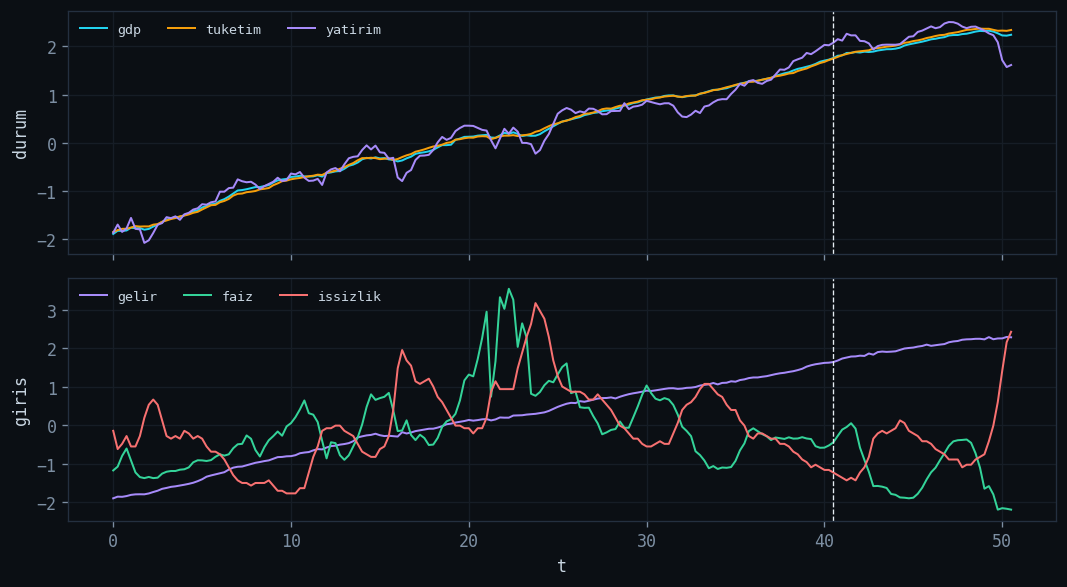

In [ ]:
sekil, eksen = plt.subplots(2, 1, figsize=(9, 5), sharex=True)
for i, ad in enumerate(["gdp", "tuketim", "yatirim"]):
    eksen[0].plot(t, olcekli[ad], color=paleta[i], lw=1.2, label=ad)
for i, ad in enumerate(["gelir", "faiz", "issizlik"]):
    eksen[1].plot(t, olcekli[ad], color=paleta[i + 2], lw=1.2, label=ad)
for e in eksen:
    e.axvline(t[kesim], color="#E6EDF3", ls="--", lw=0.8)
    e.legend(ncol=3, fontsize=8, frameon=False)
eksen[0].set_ylabel("durum")
eksen[1].set_ylabel("giris")
eksen[1].set_xlabel("t")
plt.tight_layout()
plt.show()

# MODEL

## Cebirsel · Skaler · Doğrusal

In [ ]:
tasarim = np.column_stack([giris_skaler[egitim], np.ones(kesim)])
katsayi = dogrusal_uydur(tasarim, cikis_skaler[egitim])
tahmin = katsayi[0] * giris_skaler[test] + katsayi[1]

kaydet("M01", "Cebirsel", "Skaler Dogrusal", cikis_skaler[test], tahmin)

M01 Cebirsel | Skaler Dogrusal | {'RMSE': 0.102, 'MAE': 0.0992, 'R2': 0.719}


## Cebirsel · Skaler · Doğrusal Olmayan

In [ ]:
def cebirsel_skaler(u, p):
    return p[0] * np.tanh(p[1] * u + p[2]) + p[3]


cozum = least_squares(
    lambda p: cebirsel_skaler(giris_skaler[egitim], p) - cikis_skaler[egitim],
    [1.0, 1.0, 0.0, 0.0],
)
tahmin = cebirsel_skaler(giris_skaler[test], cozum.x)

kaydet("M02", "Cebirsel", "Skaler Dogrusal Olmayan", cikis_skaler[test], tahmin)

M02 Cebirsel | Skaler Dogrusal Olmayan | {'RMSE': 0.0532, 'MAE': 0.042, 'R2': 0.9237}


## Cebirsel · Vektörel · Doğrusal

In [ ]:
tasarim = np.column_stack([giris_vektor[egitim], np.ones(kesim)])
katsayi = dogrusal_uydur(tasarim, cikis_vektor[egitim])
A, B = katsayi[:-1].T, katsayi[-1]
tahmin = giris_vektor[test] @ A.T + B

kaydet("M03", "Cebirsel", "Vektorel Dogrusal", cikis_vektor[test], tahmin)

M03

 Cebirsel | Vektorel Dogrusal | {'RMSE': 0.1215, 'MAE': 0.0807, 'R2': 0.6199}


## Cebirsel · Vektörel · Doğrusal Olmayan

In [ ]:
sekiller = [(3, 3), (3,), (3, 3), (3,)]


def cebirsel_vektorel(U, p):
    W, c, A, B = paket_ac(p, sekiller)
    return np.tanh(U @ W.T + c) @ A.T + B


baslangic = np.concatenate([np.eye(3).ravel() * 0.5, np.zeros(3), np.eye(3).ravel() * 0.5, np.zeros(3)])
cozum = least_squares(
    lambda p: (cebirsel_vektorel(giris_vektor[egitim], p) - cikis_vektor[egitim]).ravel(),
    baslangic,
)
tahmin = cebirsel_vektorel(giris_vektor[test], cozum.x)

kaydet("M04", "Cebirsel", "Vektorel Dogrusal Olmayan", cikis_vektor[test], tahmin)

M04 Cebirsel | Vektorel Dogrusal Olmayan | {'RMSE': 0.1865, 'MAE': 0.1628, 'R2': 0.1046}


## Fark · Skaler · Doğrusal

In [ ]:
tasarim = np.column_stack([durum_skaler[:kesim - 1], np.ones(kesim - 1)])
katsayi = dogrusal_uydur(tasarim, durum_skaler[1:kesim])
tahmin = katsayi[0] * durum_skaler[kesim - 1:n - 1] + katsayi[1]

kaydet("M05", "Fark", "Skaler Dogrusal", durum_skaler[test], tahmin)

M05 Fark | Skaler Dogrusal | {'RMSE': 0.0191, 'MAE': 0.0131, 'R2': 0.988}


## Fark · Skaler · Doğrusal Olmayan

In [ ]:
def fark_skaler(x, p):
    return p[0] * np.tanh(p[1] * x + p[2]) + p[3]


cozum = least_squares(
    lambda p: fark_skaler(durum_skaler[:kesim - 1], p) - durum_skaler[1:kesim],
    [1.0, 1.0, 0.0, 0.0],
)
tahmin = fark_skaler(durum_skaler[kesim - 1:n - 1], cozum.x)

kaydet("M06", "Fark", "Skaler Dogrusal Olmayan", durum_skaler[test], tahmin)

M06 Fark | Skaler Dogrusal Olmayan | {'RMSE': 0.0241, 'MAE': 0.0186, 'R2': 0.9808}


## Fark · Vektörel · Doğrusal

In [ ]:
tasarim = np.column_stack([durum_vektor[:kesim - 1], np.ones(kesim - 1)])
katsayi = dogrusal_uydur(tasarim, durum_vektor[1:kesim])
A, B = katsayi[:-1].T, katsayi[-1]
tahmin = durum_vektor[kesim - 1:n - 1] @ A.T + B

kaydet("M07", "Fark", "Vektorel Dogrusal", durum_vektor[test], tahmin)

M07 Fark | Vektorel Dogrusal | {'RMSE': 0.0673, 'MAE': 0.0367, 'R2': 0.8836}


## Fark · Vektörel · Doğrusal Olmayan

In [ ]:
def fark_vektorel(X, p):
    W, c, A, B = paket_ac(p, sekiller)
    return np.tanh(X @ W.T + c) @ A.T + B


cozum = least_squares(
    lambda p: (fark_vektorel(durum_vektor[:kesim - 1], p) - durum_vektor[1:kesim]).ravel(),
    baslangic,
)
tahmin = fark_vektorel(durum_vektor[kesim - 1:n - 1], cozum.x)

kaydet("M08", "Fark", "Vektorel Dogrusal Olmayan", durum_vektor[test], tahmin)

M08 Fark | Vektorel Dogrusal Olmayan | {'RMSE': 0.101, 'MAE': 0.0655, 'R2': 0.7372}


## Diferansiyel · Skaler · Doğrusal

In [ ]:
turev = np.gradient(durum_skaler[egitim], adim)
tasarim = np.column_stack([durum_skaler[egitim], np.ones(kesim)])
katsayi = dogrusal_uydur(tasarim, turev)
tahmin = bir_adim_ode(
    lambda zaman, durum: katsayi[0] * durum + katsayi[1],
    durum_skaler[kesim - 1:n - 1], t[kesim - 1:n - 1], adim,
)

kaydet("M09", "Diferansiyel", "Skaler Dogrusal", durum_skaler[test], tahmin)

M09 Diferansiyel | Skaler Dogrusal | {'RMSE': 0.0192, 'MAE': 0.0132, 'R2': 0.9879}


## Diferansiyel · Skaler · Doğrusal Olmayan

In [ ]:
def alan_skaler(zaman, durum, p):
    return p[0] * durum + p[1] * durum ** 2 + p[2] * np.sin(p[3] * zaman + p[4]) + p[5]


turev = np.gradient(durum_skaler[egitim], adim)
cozum = least_squares(
    lambda p: alan_skaler(t[egitim], durum_skaler[egitim], p) - turev,
    [-1.0, 0.0, 0.1, 1.0, 0.0, 0.0],
)
tahmin = bir_adim_ode(
    lambda zaman, durum: alan_skaler(zaman, durum, cozum.x),
    durum_skaler[kesim - 1:n - 1], t[kesim - 1:n - 1], adim,
)

kaydet("M10", "Diferansiyel", "Skaler Dogrusal Olmayan", durum_skaler[test], tahmin)

M10 Diferansiyel | Skaler Dogrusal Olmayan | {'RMSE': 0.0216, 'MAE': 0.0165, 'R2': 0.9847}


## Diferansiyel · Vektörel · Doğrusal

In [ ]:
turev = np.gradient(durum_vektor[egitim], adim, axis=0)
tasarim = np.column_stack([durum_vektor[egitim], np.ones(kesim)])
katsayi = dogrusal_uydur(tasarim, turev)
A, B = katsayi[:-1].T, katsayi[-1]
tahmin = bir_adim_ode(
    lambda zaman, durum: A @ durum + B,
    durum_vektor[kesim - 1:n - 1], t[kesim - 1:n - 1], adim,
)

kaydet("M11", "Diferansiyel", "Vektorel Dogrusal", durum_vektor[test], tahmin)

M11 Diferansiyel | Vektorel Dogrusal | {'RMSE': 0.063, 'MAE': 0.0366, 'R2': 0.8978}


## Diferansiyel · Vektörel · Doğrusal Olmayan

In [ ]:
sekiller_alan = [(3, 3), (3,), (3,), (3, 3), (3,)]


def alan_vektorel(zaman, durum, p):
    W, c, w, A, B = paket_ac(p, sekiller_alan)
    durum = np.atleast_2d(durum)
    return np.tanh(durum @ W.T + c + np.reshape(zaman, (-1, 1)) * w) @ A.T + B


turev = np.gradient(durum_vektor[egitim], adim, axis=0)
baslangic_alan = np.concatenate([np.eye(3).ravel() * 0.5, np.zeros(3), np.zeros(3), np.eye(3).ravel() * -0.5, np.zeros(3)])
cozum = least_squares(
    lambda p: (alan_vektorel(t[egitim], durum_vektor[egitim], p) - turev).ravel(),
    baslangic_alan,
)
tahmin = bir_adim_ode(
    lambda zaman, durum: alan_vektorel(zaman, durum, cozum.x).ravel(),
    durum_vektor[kesim - 1:n - 1], t[kesim - 1:n - 1], adim,
)

kaydet("M12", "Diferansiyel", "Vektorel Dogrusal Olmayan", durum_vektor[test], tahmin)

M12 Diferansiyel | Vektorel Dogrusal Olmayan | {'RMSE': 0.0547, 'MAE': 0.0286, 'R2': 0.9229}


## İntegral · Skaler · Doğrusal

In [ ]:
def integral_skaler(p, dilim):
    K = us_cekirdek(t, p[1])
    return temel_skaler[dilim] @ p[2:] + adim * p[0] * (K[dilim] @ durum_skaler)


cozum = least_squares(
    lambda p: integral_skaler(p, egitim) - durum_skaler[egitim],
    [0.1, 1.0, 0.0, 0.0],
)
tahmin = integral_skaler(cozum.x, test)

kaydet("M13", "Integral", "Skaler Dogrusal", durum_skaler[test], tahmin)

M13 Integral | Skaler Dogrusal | {'RMSE': 0.0995, 'MAE': 0.0747, 'R2': 0.6747}


## İntegral · Skaler · Doğrusal Olmayan

In [ ]:
def integral_skaler_dogrusalsiz(p, dilim):
    K = us_cekirdek(t, p[1])
    donusum = np.tanh(p[2] * durum_skaler + p[3])
    return temel_skaler[dilim] @ p[4:] + adim * p[0] * (K[dilim] @ donusum)


cozum = least_squares(
    lambda p: integral_skaler_dogrusalsiz(p, egitim) - durum_skaler[egitim],
    [0.1, 1.0, 1.0, 0.0, 0.0, 0.0],
)
tahmin = integral_skaler_dogrusalsiz(cozum.x, test)

kaydet("M14", "Integral", "Skaler Dogrusal Olmayan", durum_skaler[test], tahmin)

M14 Integral | Skaler Dogrusal Olmayan | {'RMSE': 0.0245, 'MAE': 0.0205, 'R2': 0.9803}


## İntegral · Vektörel · Doğrusal

In [ ]:
sekiller_integral = [(1,), (3, 3), (2, 3)]


def integral_vektorel(p, dilim):
    beta, A, C = paket_ac(p, sekiller_integral)
    K = us_cekirdek(t, beta[0])
    return temel_vektor[dilim] @ C + adim * (K[dilim] @ durum_vektor) @ A.T


cozum = least_squares(
    lambda p: (integral_vektorel(p, egitim) - durum_vektor[egitim]).ravel(),
    np.concatenate([[1.0], (np.eye(3) * 0.1).ravel(), np.zeros(6)]),
)
tahmin = integral_vektorel(cozum.x, test)

kaydet("M15", "Integral", "Vektorel Dogrusal", durum_vektor[test], tahmin)

M15 Integral | Vektorel Dogrusal | {'RMSE': 0.1328, 'MAE': 0.1068, 'R2': 0.5461}


## İntegral · Vektörel · Doğrusal Olmayan

In [ ]:
sekiller_integral_dogrusalsiz = [(1,), (3, 3), (3,), (3, 3), (2, 3)]


def integral_vektorel_dogrusalsiz(p, dilim):
    beta, W, c, A, C = paket_ac(p, sekiller_integral_dogrusalsiz)
    K = us_cekirdek(t, beta[0])
    donusum = np.tanh(durum_vektor @ W.T + c)
    return temel_vektor[dilim] @ C + adim * (K[dilim] @ donusum) @ A.T


cozum = least_squares(
    lambda p: (integral_vektorel_dogrusalsiz(p, egitim) - durum_vektor[egitim]).ravel(),
    np.concatenate([[1.0], np.eye(3).ravel(), np.zeros(3), (np.eye(3) * 0.1).ravel(), np.zeros(6)]),
)
tahmin = integral_vektorel_dogrusalsiz(cozum.x, test)

kaydet("M16", "Integral", "Vektorel Dogrusal Olmayan", durum_vektor[test], tahmin)

M16 Integral | Vektorel Dogrusal Olmayan | {'RMSE': 0.0776, 'MAE': 0.0489, 'R2': 0.8449}


# DEĞERLENDİRME

In [ ]:
turler = ["Cebirsel", "Fark", "Diferansiyel", "Integral"]
siniflar = ["Skaler Dogrusal", "Skaler Dogrusal Olmayan", "Vektorel Dogrusal", "Vektorel Dogrusal Olmayan"]

tablo = pd.DataFrame(sonuclar).T
tablo[["RMSE", "MAE", "R2"]] = tablo[["RMSE", "MAE", "R2"]].astype(float).round(4)
tablo

,Tur,Sinif,RMSE,MAE,R2
M01,Cebirsel,Skaler Dogrusal,0.1020,0.0992,0.7190
M02,Cebirsel,Skaler Dogrusal Olmayan,0.0532,0.0420,0.9237
M03,Cebirsel,Vektorel Dogrusal,0.1215,0.0807,0.6199
M04,Cebirsel,Vektorel Dogrusal Olmayan,0.1865,0.1628,0.1046
M05,Fark,Skaler Dogrusal,0.0191,0.0131,0.9880
M06,Fark,Skaler Dogrusal Olmayan,0.0241,0.0186,0.9808
M07,Fark,Vektorel Dogrusal,0.0673,0.0367,0.8836
M08,Fark,Vektorel Dogrusal Olmayan,0.1010,0.0655,0.7372
M09,Diferansiyel,Skaler Dogrusal,0.0192,0.0132,0.9879
M10,Diferansiyel,Skaler Dogrusal Olmayan,0.0216,0.0165,0.9847


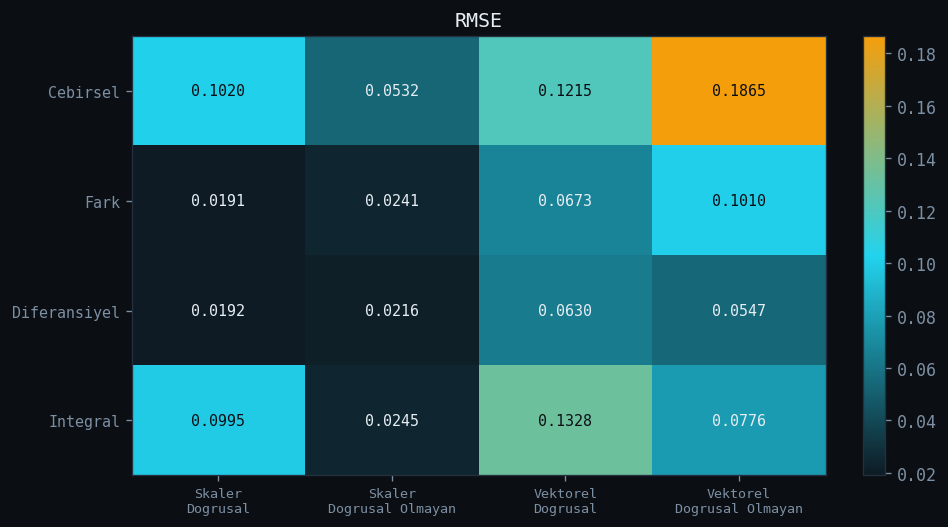

In [ ]:
izgara = tablo.pivot_table(index="Tur", columns="Sinif", values="RMSE").loc[turler, siniflar]

deger = izgara.to_numpy()
oran = (deger - deger.min()) / (deger.max() - deger.min())

sekil, eksen = plt.subplots(figsize=(8, 4.5))
resim = eksen.imshow(deger, cmap=harita, aspect="auto")
for i in range(4):
    for j in range(4):
        eksen.text(j, i, f"{deger[i, j]:.4f}", ha="center", va="center",
                   color="#0B0F14" if oran[i, j] > 0.35 else "#E6EDF3", fontsize=9)
eksen.set_xticks(range(4), ["Skaler\nDogrusal", "Skaler\nDogrusal Olmayan", "Vektorel\nDogrusal", "Vektorel\nDogrusal Olmayan"], fontsize=8)
eksen.set_yticks(range(4), turler, fontsize=9)
eksen.set_title("RMSE")
eksen.grid(False)
sekil.colorbar(resim, ax=eksen, fraction=0.03)
plt.tight_layout()
plt.show()

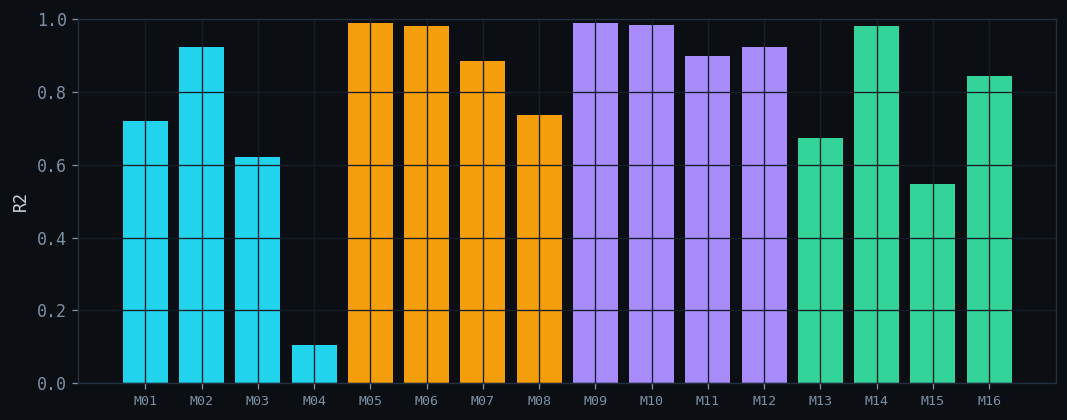

In [ ]:
sira = list(sonuclar.keys())
degerler = [sonuclar[k]["R2"] for k in sira]
renkler = [paleta[turler.index(sonuclar[k]["Tur"])] for k in sira]

sekil, eksen = plt.subplots(figsize=(9, 3.6))
eksen.bar(sira, degerler, color=renkler)
eksen.set_ylim(0, 1)
eksen.set_ylabel("R2")
eksen.tick_params(axis="x", labelsize=8)
plt.tight_layout()
plt.show()

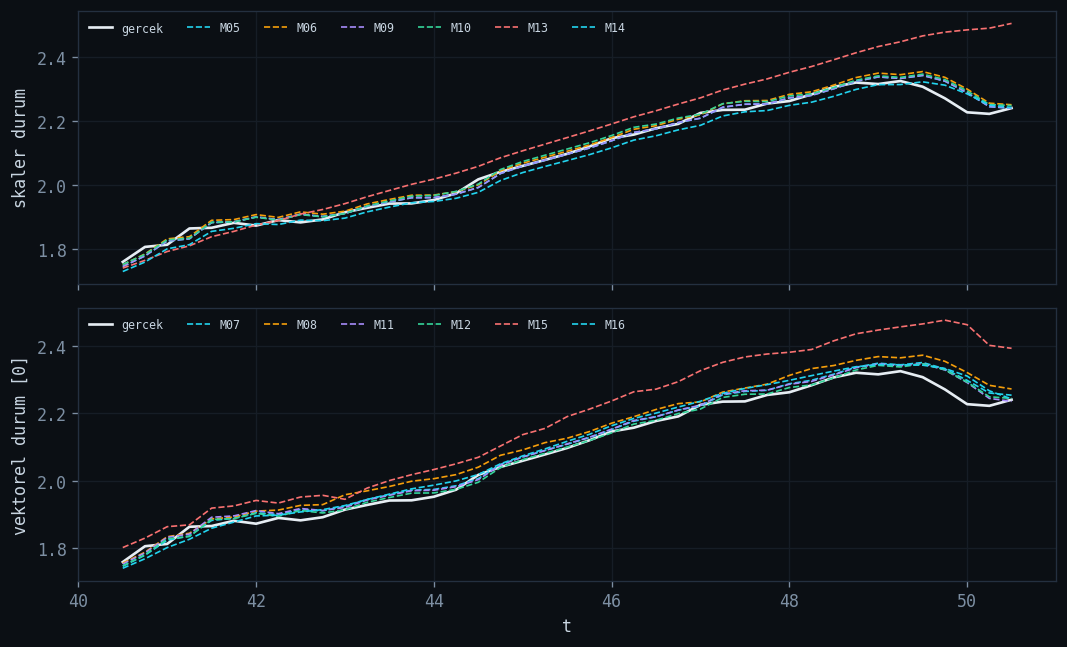

In [ ]:
sekil, eksen = plt.subplots(2, 1, figsize=(9, 5.5), sharex=True)
zaman = t[test]

eksen[0].plot(zaman, durum_skaler[test], color="#E6EDF3", lw=1.6, label="gercek")
for i, kod in enumerate(["M05", "M06", "M09", "M10", "M13", "M14"]):
    eksen[0].plot(zaman, np.ravel(tahminler[kod]), color=paleta[i % len(paleta)], lw=1.0, ls="--", label=kod)

eksen[1].plot(zaman, durum_vektor[test, 0], color="#E6EDF3", lw=1.6, label="gercek")
for i, kod in enumerate(["M07", "M08", "M11", "M12", "M15", "M16"]):
    eksen[1].plot(zaman, np.asarray(tahminler[kod])[:, 0], color=paleta[i % len(paleta)], lw=1.0, ls="--", label=kod)

eksen[0].set_ylabel("skaler durum")
eksen[1].set_ylabel("vektorel durum [0]")
eksen[1].set_xlabel("t")
for e in eksen:
    e.legend(ncol=7, fontsize=7, frameon=False)
plt.tight_layout()
plt.show()

In [ ]:
tablo.sort_values("RMSE")[["Tur", "Sinif", "RMSE", "MAE", "R2"]]

,Tur,Sinif,RMSE,MAE,R2
M05,Fark,Skaler Dogrusal,0.0191,0.0131,0.9880
M09,Diferansiyel,Skaler Dogrusal,0.0192,0.0132,0.9879
M10,Diferansiyel,Skaler Dogrusal Olmayan,0.0216,0.0165,0.9847
M06,Fark,Skaler Dogrusal Olmayan,0.0241,0.0186,0.9808
M14,Integral,Skaler Dogrusal Olmayan,0.0245,0.0205,0.9803
M02,Cebirsel,Skaler Dogrusal Olmayan,0.0532,0.0420,0.9237
M12,Diferansiyel,Vektorel Dogrusal Olmayan,0.0547,0.0286,0.9229
M11,Diferansiyel,Vektorel Dogrusal,0.0630,0.0366,0.8978
M07,Fark,Vektorel Dogrusal,0.0673,0.0367,0.8836
M16,Integral,Vektorel Dogrusal Olmayan,0.0776,0.0489,0.8449
